# Continuous-time linear demo
These are not actual experiments, but anyway demonstrate how the routines are used.

In [1]:
import numpy as np
from scipy import linalg
from cmap.clqt_jax import CLQT
from cmap.Linear_model_jax import getCLQT 
import jax
import matplotlib.pyplot as plt
from jax import config
import jax.numpy as jnp
from cmap.Linear_model_data import make_cv_data
config.update("jax_enable_x64", True)

This is how the continuous version of the tracking data is formed

In [2]:
# nsteps = 5000
# x0=jnp.array([7.0,7.0,3.0,3.0])
# dt=0.01
# P0=0.1*np.eye(4)
# q=0.2
# r=0.01
# T, X, dotz, Y,dotz2=make_cv_data( x0, P0,nsteps, dt, q, r, seed=123)

In [3]:
# t_grid = np.arange(nsteps) * dt
# s=jnp.stack([dotz(t) for t in t_grid], axis=0)
# # print(dotz(0.35))
# # call the function at every time point
# DY_dt_recovered = np.stack([dotz(t) for t in t_grid], axis=0)
# np.shape(DY_dt_recovered)
# # np.savetxt('con-meas.txt',dotz)

In [4]:
# plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
# plt.plot(X[:,0], X[:,1], label='True velocity x')
# print(DY_dt_recovered[:,0])

Apply control and show the result

In [5]:
from cmap.KB import kalman_bucy_filter
from cmap.KB import continuous_rts_smoother


In [6]:

cx = jnp.array([5.7770, -2.6692, 1.1187, 0.1379, 0.5718, 1.1214,
                0.2998, 0.3325, 0.7451, 0.2117, 0.6595, 0.0401, -0.2995])
cy = jnp.array([4.3266, -1.4584, -1.2457, 1.1804, 0.2035, 0.5123,
                1.0588, 0.2616, -0.6286, -0.3802, 0.2750, -0.0070, -0.0022])

y = lambda t: jnp.array([cx[0] +
             cx[1] * jnp.cos(2.0 * jnp.pi * t / 50.0) + cx[2] * jnp.sin(2.0 * jnp.pi * t / 50.0) +
               cx[3] * jnp.cos(4.0 * jnp.pi * t / 50.0) + cx[4] * jnp.sin(4.0 * jnp.pi * t / 50.0) +
               cx[5] * jnp.cos(6.0 * jnp.pi * t / 50.0) + cx[6] * jnp.sin(6.0 * jnp.pi * t / 50.0) +
               cx[7] * jnp.cos(8.0 * jnp.pi * t / 50.0) + cx[8] * jnp.sin(8.0 * jnp.pi * t / 50.0) +
               cx[9] * jnp.cos(10.0 * jnp.pi * t / 50.0) + cx[10] * jnp.sin(10.0 * jnp.pi * t / 50.0) +
               cx[11] * jnp.cos(12.0 * jnp.pi * t / 50.0) + cx[12] * jnp.sin(12.0 * jnp.pi * t / 50.0),
               cy[0] +
               cy[1] * jnp.cos(2.0 * jnp.pi * t / 50.0) + cy[2] * jnp.sin(2.0 * jnp.pi * t / 50.0) +
               cy[3] * jnp.cos(4.0 * jnp.pi * t / 50.0) + cy[4] * jnp.sin(4.0 * jnp.pi * t / 50.0) +
              cy[5] * jnp.cos(6.0 * jnp.pi * t / 50.0) + cy[6] * jnp.sin(6.0 * jnp.pi * t / 50.0) +
              cy[7] * jnp.cos(8.0 * jnp.pi * t / 50.0) + cy[8] * jnp.sin(8.0 * jnp.pi * t / 50.0) +
              cy[9] * jnp.cos(10.0 * jnp.pi * t / 50.0) + cy[10] * jnp.sin(10.0 * jnp.pi * t / 50.0) +
              cy[11] * jnp.cos(12.0 * jnp.pi * t / 50.0) + cy[12] * jnp.sin(12.0 * jnp.pi * t / 50.0)
                     ])

F = lambda t: jnp.array([[0.,0,1,0],
               [0,0,0,1],
               [0,0,0,0],
               [0,0,0,0]])
L = lambda t: jnp.array([[0,0],[0,0],[1,0],[0,1]])
H = lambda t: jnp.array([[1,0,0,0],[0,1,0,0]])
Q = lambda t: jnp.eye(2) * 0.2
R = lambda t:jnp.eye(2) * 0.01


Sigma = 1 * jnp.eye(4)
x0=jnp.array([5.0,5.0,0.0,0.0])
t0= 0.0
dt=0.01
step_seq=5000

t_eval = t0 + dt * np.arange(step_seq)
y_discrete = np.array([y(tk) for tk in t_eval])


Ps,ms = kalman_bucy_filter(F, L, Q, H, R, y, step_seq, dt,t0, Sigma, x0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, Q, t_eval, dt)


4999
4998
4997
4996
4995
4994
4993
4992
4991
4990
4989
4988
4987
4986
4985
4984
4983
4982
4981
4980
4979
4978
4977
4976
4975
4974
4973
4972
4971
4970
4969
4968
4967
4966
4965
4964
4963
4962
4961
4960
4959
4958
4957
4956
4955
4954
4953
4952
4951
4950
4949
4948
4947
4946
4945
4944
4943
4942
4941
4940
4939
4938
4937
4936
4935
4934
4933
4932
4931
4930
4929
4928
4927
4926
4925
4924
4923
4922
4921
4920
4919
4918
4917
4916
4915
4914
4913
4912
4911
4910
4909
4908
4907
4906
4905
4904
4903
4902
4901
4900
4899
4898
4897
4896
4895
4894
4893
4892
4891
4890
4889
4888
4887
4886
4885
4884
4883
4882
4881
4880
4879
4878
4877
4876
4875
4874
4873
4872
4871
4870
4869
4868
4867
4866
4865
4864
4863
4862
4861
4860
4859
4858
4857
4856
4855
4854
4853
4852
4851
4850
4849
4848
4847
4846
4845
4844
4843
4842
4841
4840
4839
4838
4837
4836
4835
4834
4833
4832
4831
4830
4829
4828
4827
4826
4825
4824
4823
4822
4821
4820
4819
4818
4817
4816
4815
4814
4813
4812
4811
4810
4809
4808
4807
4806
4805
4804
4803
4802
4801
4800


In [7]:
import jax.numpy as jnp
import cmap.Linear_model_jax as linear_model_jax
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass


In [8]:
clqt, x0 = getCLQT(CLQT)

blocks = 500
steps = 10
t0 = 0.0
dt = clqt.T / steps / blocks
sigma=clqt.Sigma(0)
mu=clqt.mu


S_list_jax_seq, v_list_jax_seq,Kx_list_jax_seq, d_list_jax_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,sigma,sigma@mu)
phi0= np.linalg.solve(S_list_jax_seq[0] ,v_list_jax_seq[0])
phis=np.linalg.solve(S_list_jax_seq ,v_list_jax_seq)
x_list_jax_seq,u_list_jax_seq =seqForwardPass(clqt, dt, 50, phi0, Kx_list_jax_seq, d_list_jax_seq,u_zoh=False)


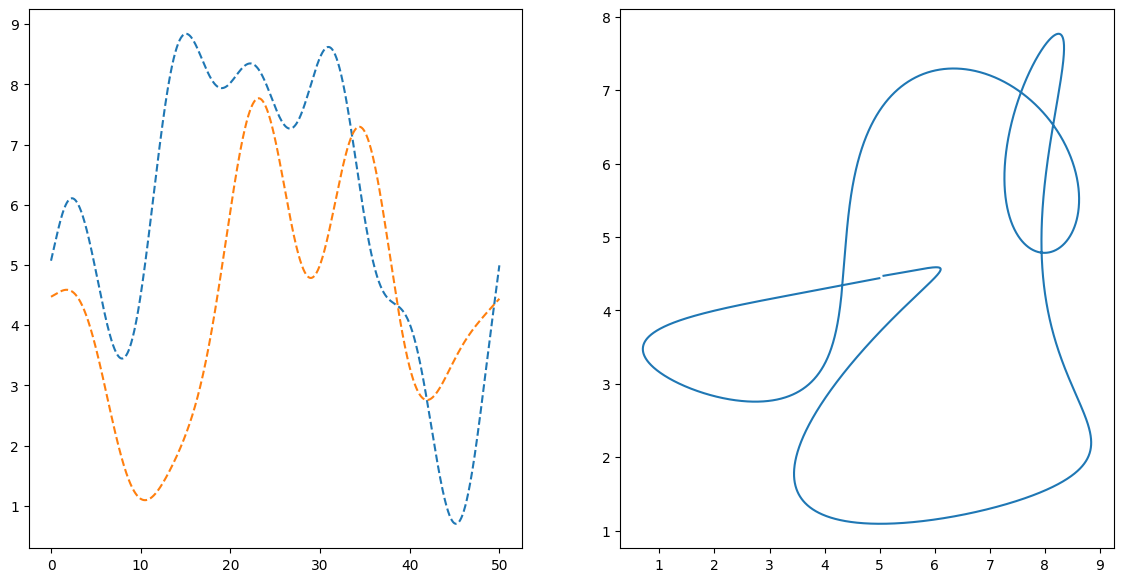

In [9]:
xs3 = np.array(x_list_jax_seq)[::-1]
us3 = np.array(u_list_jax_seq)
tt1 = np.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])
# ax2.plot( ms_s[:,0],ms_s[:,1])
# ax2.plot(positions[:,0], positions[:,1])

In [10]:
clqt, x0 = getCLQT(CLQT)


t0 = 0.0
dt = clqt.T / steps / blocks
Kx_list, d_list, S_list, v_list = parBackwardPass(clqt,blocks,steps,t0,dt)
phi0= np.linalg.solve(S_list[0] ,v_list[0])
phis1=np.linalg.solve(S_list ,v_list)

u_list,x_list = parForwardPass(clqt, phi0, Kx_list, d_list, blocks, steps,dt,t0,u_zoh=False)



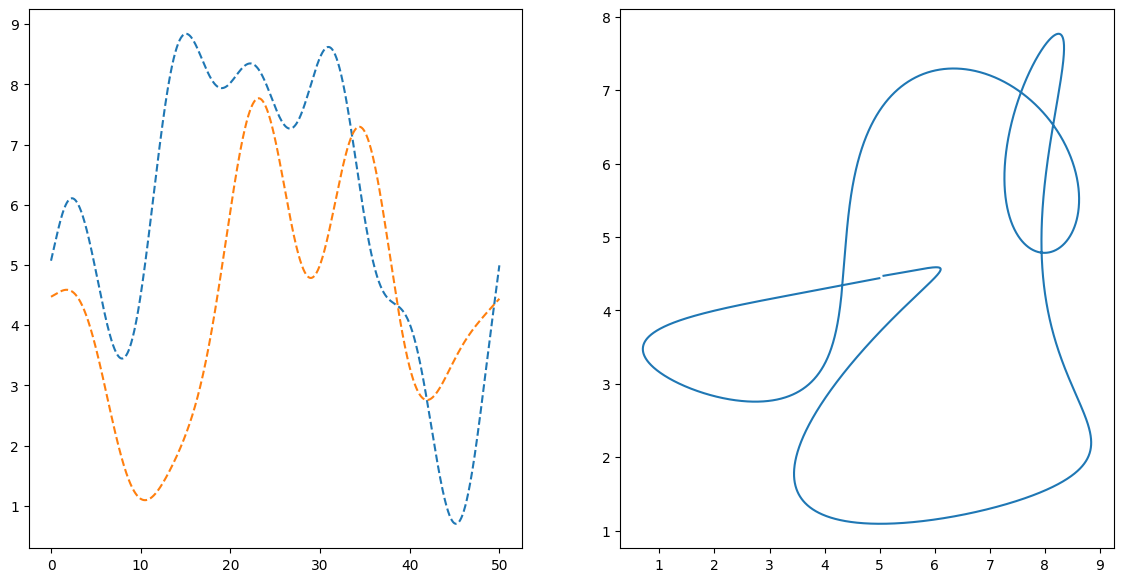

In [11]:
xs4 = np.array(x_list)[::-1]

us4 = np.array(u_list)
tt1 = np.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


In [12]:
err = jnp.max(jnp.abs(xs4- xs3))
results=jnp.hstack((xs3,xs4))
print(err)

4.91739515773304e-09


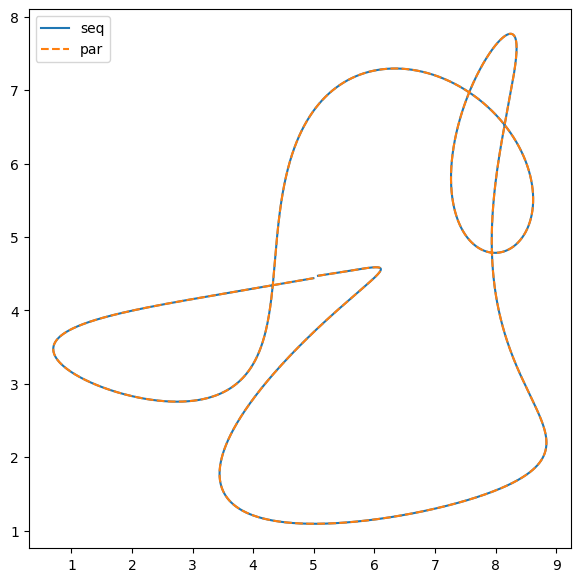

In [13]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1],'--')
ax1.legend( ['seq', 'par'])


In [14]:
jax.numpy.allclose(xs3, xs4, rtol=1e-7)

Array(True, dtype=bool)

In [15]:
jax.numpy.allclose(xs3, ms_s, rtol=1e-1)

Array(False, dtype=bool)

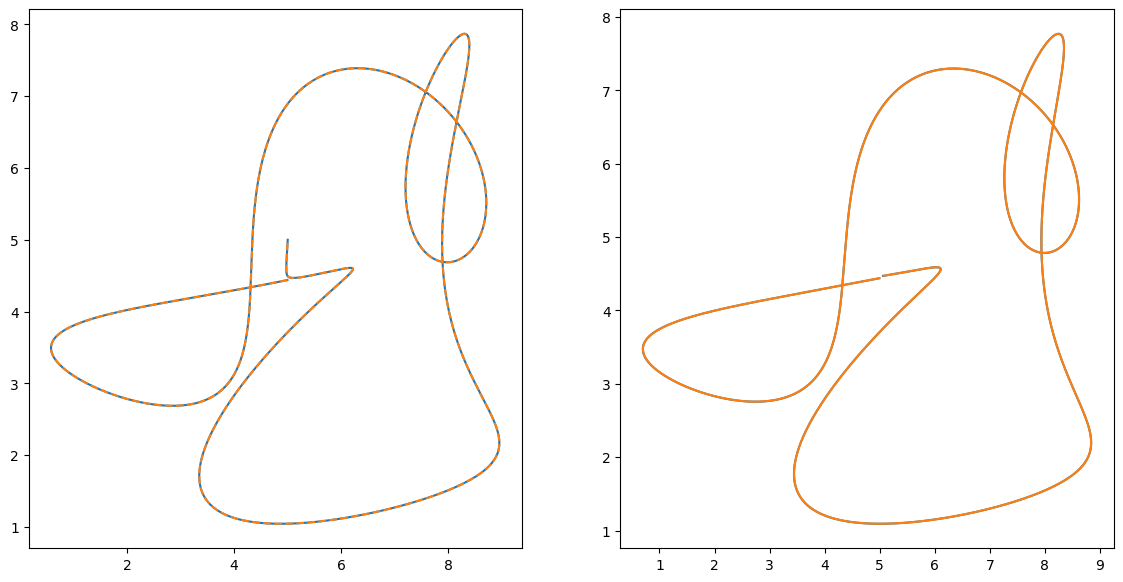

In [16]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))


ax1.plot(ms[:,0], ms[:,1])
ax1.plot(phis[:,0], phis[:,1], '--')
ax2.plot(ms_s[:,0], ms_s[:,1])
ax2.plot(xs3[:,0], xs3[:,1])

In [17]:
print(jnp.mean(jnp.abs(xs3-ms_s)))

0.005732947444106237


In [19]:
print(jnp.mean(jnp.abs(phis[::-1]-ms)))

6.743597389919191e-06
